In [2]:

from thermopy.properties import fugacity
from thermopy.eos import PengRobinson
from thermopy.constants import R
import numpy as np
import matplotlib.pyplot as plt
from thermopy.species import get_species



## Textbook Graphs
### To demonstrate non-ideal behaviour using the Peng-Robinson equation of state graphs similar to those available in chapter 3 of Introduction to Chemical Engineering Thermodynamics [1] can be produced using reduced pressure and several isotherms in reduced temperature<br>


[1] Smith, J.M., Van Ness, H.C., Abbott, M.M., and Swihart, M.T., Introduction to Chemical Engineering Thermodynamics, 9th ed., McGraw-Hill Education, New York, 2022.

### Z against Pr for $Tr = [0.9, 1.0, 1.2, 1.5, 2.0] $
#### Both the vapour region and the compressed region can be observed

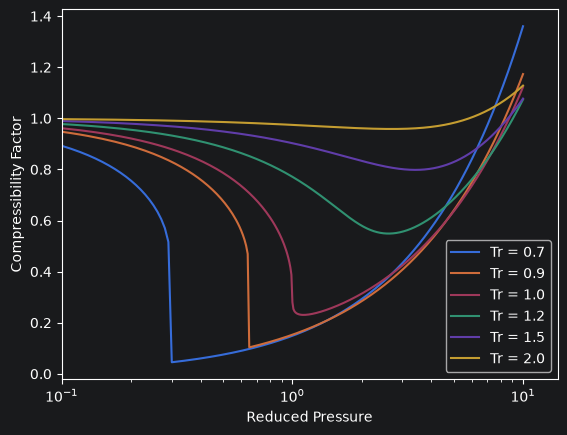

In [6]:
"""Instantiate EoS object for methane - methane can be changed to another accepted species"""
PR = PengRobinson("hydrogen sulphide")
Tc = PR.Tc
Pc = PR.Pc

Pr_range = np.linspace(0, 10, 1000)
Tr_range = [0.7,0.9, 1.0,1.2,1.5,2.0] #Isotherms

for Tr in Tr_range:
    Zs = []
    T = Tc*Tr #definition of reduced temperature
    for Pr in Pr_range:
        p=Pr*Pc
        state = PR.solve(T, p)
        state = state[-1] #Only use largest Z root, either vapour/supercritical or compressed liquid

        Zs.append(state.Z)
    plt.plot(Pr_range, Zs, label=f"Tr = {Tr}")

plt.xlabel("Reduced Pressure")
plt.xscale("log")
plt.xlim(left=10**-1)
plt.ylabel("Compressibility Factor")
plt.legend()
plt.show()

## $\phi$ against Pr for $Tr = [0.7,0.8,0.9,1.0,1.1,1.5, 2.0]$

In [ ]:
"""methane can be substituted for another available species"""
PR = PengRobinson("methane")
Pc = PR.Pc
Tc = PR.Tc

Pr_range = np.linspace(0, 10, 1000)
Tr_range = [0.7,0.8,0.9,1.0,1.1,1.5, 2.0]

for Tr in Tr_range:
    phis = []
    T=Tr*Tc
    for Pr in Pr_range:
        p = Pr*Pc

        state = PR.solve(T, p)
        state = state[-1]

        phi = fugacity.coefficient(state, PR, cubicEoS=True)
        phis.append(phi)

    plt.plot(Pr_range,phis, label=f"Tr={Tr}")

plt.xlabel("Reduced Pressure")
plt.ylabel("Fugacity Coefficient")
plt.legend()
plt.show()

